In [ ]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import timm

In [ ]:
# === Parameters ===
train_dir = '/content/drive/MyDrive/Hands40/train'
val_dir   = '/content/drive/MyDrive/Hands40/val'
test_dir  = '/content/drive/MyDrive/Hands40/test'
num_classes = 40
batch_size = 32
image_size = 224
epochs = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
# === Transforms ===
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# === Datasets ===
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# === Model ===
model = timm.create_model('tf_efficientnetv2_s', pretrained=True, num_classes=40)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

In [ ]:
# === Train/Eval Functions ===
def train(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
            total += y.size(0)
    return total_loss / total, correct / total, preds, labels

In [ ]:
# === Training Loop ===
train_accs, val_accs = [], []
train_losses, val_losses = [], []

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Train Loss: {train_loss:.4f}, Val Acc: {val_acc:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1/50 - Train Acc: 0.0660, Train Loss: 4.6646, Val Acc: 0.1950, Val Loss: 3.3773
Epoch 2/50 - Train Acc: 0.2384, Train Loss: 3.0395, Val Acc: 0.3648, Val Loss: 2.5969
Epoch 3/50 - Train Acc: 0.4046, Train Loss: 2.3851, Val Acc: 0.4780, Val Loss: 1.9352
Epoch 4/50 - Train Acc: 0.5196, Train Loss: 1.8618, Val Acc: 0.6164, Val Loss: 1.4841
Epoch 5/50 - Train Acc: 0.6638, Train Loss: 1.3463, Val Acc: 0.7421, Val Loss: 1.0111
Epoch 6/50 - Train Acc: 0.7152, Train Loss: 1.1284, Val Acc: 0.7925, Val Loss: 0.7846
Epoch 7/50 - Train Acc: 0.7689, Train Loss: 0.8964, Val Acc: 0.8428, Val Loss: 0.5671
Epoch 8/50 - Train Acc: 0.8215, Train Loss: 0.7532, Val Acc: 0.8742, Val Loss: 0.4696
Epoch 9/50 - Train Acc: 0.8350, Train Loss: 0.6473, Val Acc: 0.9057, Val Loss: 0.3695
Epoch 10/50 - Train Acc: 0.8533, Train Loss: 0.5586, Val Acc: 0.9308, Val Loss: 0.2876
Epoch 11/50 - Train Acc: 0.8643, Train Loss: 0.5401, Val Acc: 0.9245, Val Loss: 0.2643
Epoch 12/50 - Train Acc: 0.8778, Train Loss: 0.4813,

In [ ]:
# === Test Evaluation ===
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\n✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


✅ Test Accuracy: 0.9727, Test Loss: 0.1163


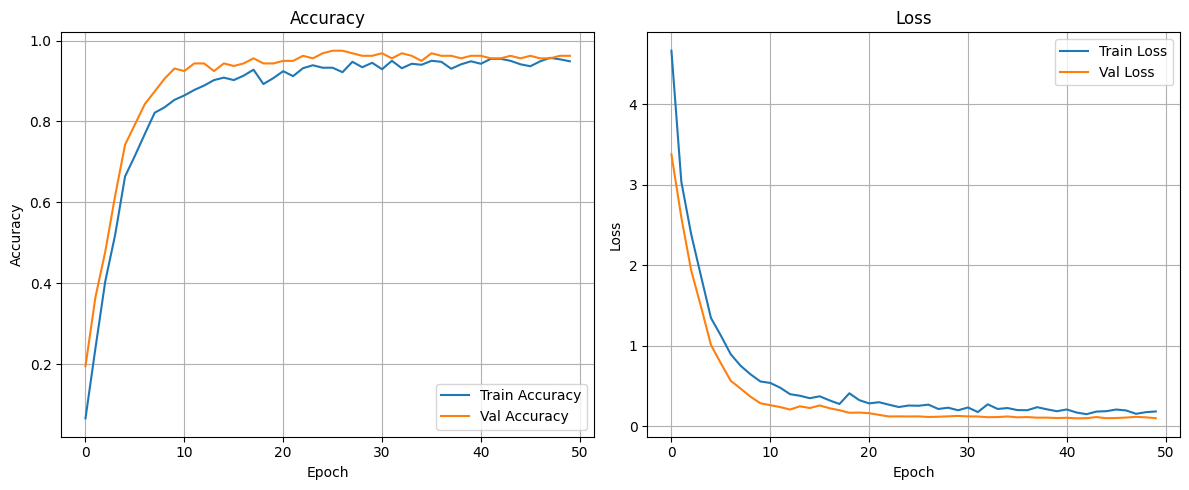

In [ ]:
# === Accuracy & Loss Plot ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

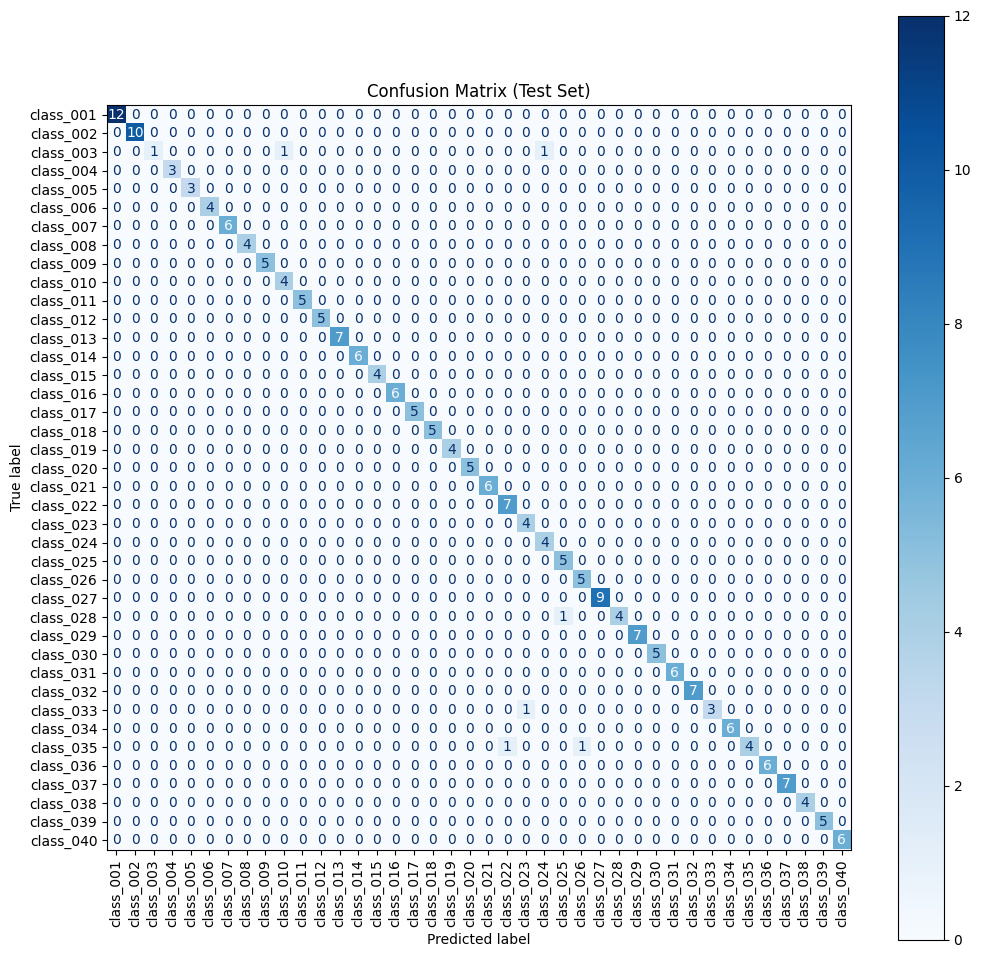

In [ ]:
# === Confusion Matrix ===
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()